In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Activation, Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix

import itertools
import os
import shutil
import random
import glob
import warnings
import matplotlib.pyplot as plt
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = '/content/drive/MyDrive/Forest_Fire/train'
#valid_path = '/content/drive/MyDrive/cats vs dogs/valid'
test_path = '/content/drive/MyDrive/Forest_Fire/test'

In [ ]:
import os

train_path = '/content/drive/MyDrive/Forest_Fire/train'
test_path = '/content/drive/MyDrive/Forest_Fire/test'

print("Train folders:", os.listdir(train_path))
for folder in os.listdir(train_path):
    print(f"{folder}: {len(os.listdir(os.path.join(train_path, folder)))} images")

print("\nTest folders:", os.listdir(test_path))
for folder in os.listdir(test_path):
    print(f"{folder}: {len(os.listdir(os.path.join(test_path, folder)))} images")


Train folders: ['Smoke', 'fire', 'non fire']
Smoke: 10800 images
fire: 10800 images
non fire: 10800 images

Test folders: ['Smoke', 'non fire', 'fire']
Smoke: 3500 images
non fire: 3500 images
fire: 3500 images


In [ ]:
import os
from PIL import Image
from tqdm import tqdm

# Set your paths
root_dir = '/content/drive/MyDrive/Forest_Fire'
target_size = (224, 224)  # You can change to (256, 256) if you want slightly larger
processed_dir = '/content/drive/MyDrive/Forest_Fire_resized'  # new folder for resized images

os.makedirs(processed_dir, exist_ok=True)

def resize_images(src_folder, dest_folder, size):
    os.makedirs(dest_folder, exist_ok=True)
    for cls in os.listdir(src_folder):
        cls_path = os.path.join(src_folder, cls)
        if not os.path.isdir(cls_path):
            continue
        dest_cls_path = os.path.join(dest_folder, cls)
        os.makedirs(dest_cls_path, exist_ok=True)
        for fname in tqdm(os.listdir(cls_path), desc=f"Resizing {cls}"):
            fpath = os.path.join(cls_path, fname)
            if not os.path.isfile(fpath):
                continue
            try:
                img = Image.open(fpath).convert('RGB')
                img = img.resize(size, Image.Resampling.LANCZOS)
                img.save(os.path.join(dest_cls_path, fname))
            except Exception as e:
                print(f"⚠️ Error resizing {fname}: {e}")

# Resize train and test
for split in ['train', 'test']:
    src = os.path.join(root_dir, split)
    dest = os.path.join(processed_dir, split)
    resize_images(src, dest, target_size)

print("✅ All images resized successfully and saved in:", processed_dir)


Resizing fire: 100%|██████████| 3500/3500 [05:29<00:00, 10.63it/s]

✅ All images resized successfully and saved in: /content/drive/MyDrive/Forest_Fire_resized


In [ ]:
import os
from PIL import Image
from tqdm import tqdm

SRC_ROOT = '/content/drive/MyDrive/Forest_Fire_resized'  # your resized set or original
OUT_ROOT = '/content/drive/MyDrive/Forest_Fire_cleaned'
os.makedirs(OUT_ROOT, exist_ok=True)

def convert_folder(src_root, out_root):
    for split in ['train','test']:
        sroot = os.path.join(src_root, split)
        oroot = os.path.join(out_root, split)
        for cls in os.listdir(sroot):
            src_c = os.path.join(sroot, cls)
            dst_c = os.path.join(oroot, cls)
            os.makedirs(dst_c, exist_ok=True)
            for fname in tqdm(os.listdir(src_c), desc=f"{split}/{cls}"):
                sfile = os.path.join(src_c, fname)
                try:
                    with Image.open(sfile) as im:
                        im = im.convert('RGB')
                        # save as jpg to standardize extension
                        base = os.path.splitext(fname)[0]
                        out_path = os.path.join(dst_c, base + '.jpg')
                        im.save(out_path, quality=95)
                except Exception as e:
                    print("skipping", sfile, e)

convert_folder(SRC_ROOT, OUT_ROOT)
print("done — cleaned images in:", OUT_ROOT)


test/fire: 100%|██████████| 3500/3500 [01:24<00:00, 41.49it/s]

done — cleaned images in: /content/drive/MyDrive/Forest_Fire_cleaned


In [ ]:
import os

DATA_ROOT = "/content/drive/MyDrive/Forest_Fire_cleaned"

for split in ["train", "test"]:
    print(f"\n📂 {split.upper()} FOLDER")
    split_path = os.path.join(DATA_ROOT, split)

    if not os.path.exists(split_path):
        print("Folder not found:", split_path)
        continue

    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            num_images = len([f for f in os.listdir(cls_path)
                              if os.path.isfile(os.path.join(cls_path, f))])
            print(f"  - {cls}: {num_images} images")



📂 TRAIN FOLDER
  - Smoke: 9188 images
  - fire: 8134 images
  - non fire: 10339 images

📂 TEST FOLDER
  - Smoke: 2356 images
  - fire: 1670 images
  - non fire: 3476 images


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

TRAIN_DIR = '/content/drive/MyDrive/Forest_Fire_cleaned/train'
TEST_DIR  = '/content/drive/MyDrive/Forest_Fire_cleaned/test'

# -------------------------------------------------------------------
# 1) Load datasets (Keras handles resizing)
# -------------------------------------------------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode='int',
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode='int',
    shuffle=False
)

# -------------------------------------------------------------------
# 2) Augmentation model (SAFE for batch tensors, NO expand_dims)
# -------------------------------------------------------------------
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),

    # brightness & contrast help smoke/fire variability
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.20),

], name="forest_fire_augmentation")

# -------------------------------------------------------------------
# 3) EfficientNet preprocessing
# -------------------------------------------------------------------
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

# -------------------------------------------------------------------
# 4) Training preprocessing (augmentation + noise + efficientnet)
# -------------------------------------------------------------------
def augment_and_preprocess(image, label):
    # Convert uint8 → float32 (0..1)
    image = tf.image.convert_image_dtype(image, tf.float32)

    # Augmentation (FREE of shape errors)
    image = augmentation(image, training=True)

    # Gaussian noise for robustness
    noise = tf.random.normal(
        tf.shape(image),
        mean=0.0,
        stddev=0.015,
        dtype=image.dtype          # <-- FIXED dtype mismatch
    )
    image = tf.clip_by_value(image + noise, 0.0, 1.0)

    # EfficientNet expects input 0..255
    image = preprocess_input(image * 255.0)

    return image, label

# -------------------------------------------------------------------
# 5) Validation preprocessing (NO augmentation)
# -------------------------------------------------------------------
def preprocess_only(image, label):
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = preprocess_input(image * 255.0)
    return image, label

# -------------------------------------------------------------------
# 6) Build final dataset pipelines
# -------------------------------------------------------------------
train_ds = (
    train_ds
    .map(augment_and_preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess_only, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("✨ Final augmentation pipeline ready — correct, stable, no dtype or shape errors.")


Found 27661 files belonging to 3 classes.
Found 7502 files belonging to 3 classes.
✨ Final augmentation pipeline ready — correct, stable, no dtype or shape errors.


In [ ]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# EfficientNetB0 training pipeline optimized for speed+accuracy
# Paste entire cell in Colab and run. Adjust BATCH if OOM.

import os, math, glob, random, time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# ---------------- USER SETTINGS ----------------
DATA_ROOT = '/content/drive/MyDrive/Forest_Fire_cleaned'
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'test')

TFREC_DIR = os.path.join(DATA_ROOT, 'tfrecords')   # where TFRecords will be stored
os.makedirs(TFREC_DIR, exist_ok=True)

IMG_SIZE = (224, 224)     # use 224 for better accuracy
BATCH = 32                # try 32; reduce to 16 if OOM
AUTOTUNE = tf.data.AUTOTUNE

# Training schedule (tweak to meet time budget)
HEAD_EPOCHS = 3
FINE_TUNE_EPOCHS = 8
BASE_LR = 1e-4

CACHE_TRAIN = '/content/cache_train_eff'
CACHE_VAL   = '/content/cache_val_eff'
os.makedirs(os.path.dirname(CACHE_TRAIN), exist_ok=True)

CHECKPOINT_DIR = os.path.join(DATA_ROOT, 'effnet_checkpoints'); os.makedirs(CHECKPOINT_DIR, exist_ok=True)
LOG_CSV = os.path.join(DATA_ROOT, 'effnet_training_log.csv')

# If you want shorter runs to ensure finishing within time, override these:
# STEPS_PER_EPOCH = 200
# VALIDATION_STEPS = 50
STEPS_PER_EPOCH = None   # None => use full dataset steps (recommended)
VALIDATION_STEPS = None

# ---------------- Speed features ----------------
tf.config.optimizer.set_jit(True)  # XLA
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision:", mixed_precision.global_policy())
except Exception as e:
    print("Mixed precision not available:", e)

# ---------------- helpers to create TFRecords (one-time) ----------------
def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def image_example(image_bytes, label):
    return tf.train.Example(features=tf.train.Features(feature={
        'image': _bytes_feature(image_bytes),
        'label': _int64_feature(int(label)),
    }))

def write_tfrecord(split_dir, out_path):
    files = []
    classes = sorted([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))])
    for idx, cls in enumerate(classes):
        cls_path = os.path.join(split_dir, cls)
        for fname in os.listdir(cls_path):
            p = os.path.join(cls_path, fname)
            if os.path.isfile(p):
                files.append((p, idx))
    random.shuffle(files)
    with tf.io.TFRecordWriter(out_path) as writer:
        for p, lbl in files:
            try:
                img_bytes = tf.io.read_file(p).numpy()
                ex = image_example(img_bytes, lbl)
                writer.write(ex.SerializeToString())
            except Exception as e:
                print("skip:", p, e)

train_tfr = os.path.join(TFREC_DIR, 'train.tfrecord')
val_tfr   = os.path.join(TFREC_DIR, 'val.tfrecord')

if not (os.path.exists(train_tfr) and os.path.exists(val_tfr)):
    print("Creating TFRecords (one-time) — this may take a few minutes.")
    write_tfrecord(TRAIN_DIR, train_tfr)
    write_tfrecord(VAL_DIR, val_tfr)
    print("TFRecords created:", train_tfr, val_tfr)
else:
    print("TFRecords found, using existing files.")

# ---------------- parse TFRecord -> dataset ----------------
feature_description = {
    'image': tf.io.FixedLenFeature([], tf.string),
    'label': tf.io.FixedLenFeature([], tf.int64),
}

def parse_tfr(example_proto, img_size=IMG_SIZE, training=True):
    ex = tf.io.parse_single_example(example_proto, feature_description)
    img = tf.io.decode_image(ex['image'], channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)  # 0..1
    # preserve aspect ratio & pad then resize
    img = tf.image.resize_with_pad(img, max(img_size), max(img_size))
    img = tf.image.resize(img, img_size)
    label = tf.cast(ex['label'], tf.int32)
    if training:
        # cheap vectorized augmentation
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.12)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        # small random crop/zoom
        scale = tf.random.uniform([], 0.92, 1.0)
        new_size = tf.cast(tf.cast(img_size, tf.float32) * scale, tf.int32)
        img = tf.image.resize(img, new_size)
        img = tf.image.resize_with_crop_or_pad(img, img_size[0], img_size[1])
        noise = tf.random.normal(tf.shape(img), stddev=0.01, dtype=img.dtype)
        img = tf.clip_by_value(img + noise, 0.0, 1.0)
    # EfficientNet preprocess expects 0..255
    img = tf.keras.applications.efficientnet.preprocess_input(img * 255.0)
    return img, label

def make_tfr_dataset(tfr_path, batch=BATCH, training=True, shuffle_buffer=20000):
    ds = tf.data.TFRecordDataset(tfr_path, num_parallel_reads=AUTOTUNE)
    if training:
        ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda x: parse_tfr(x, training=training), num_parallel_calls=AUTOTUNE)
    ds = ds.cache(CACHE_TRAIN if training else CACHE_VAL)   # caches parsed tensors (fast)
    ds = ds.batch(batch)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_tfr_dataset(train_tfr, batch=BATCH, training=True)
val_ds   = make_tfr_dataset(val_tfr, batch=BATCH, training=False)

# ---------------- compute dataset sizes & steps ----------------
# Count records in TFRecord quickly (fallback to folder count)
def count_tfrecord_records(tfr):
    count = 0
    for _ in tf.data.TFRecordDataset(tfr):
        count += 1
    return count

try:
    n_train = count_tfrecord_records(train_tfr)
    n_val   = count_tfrecord_records(val_tfr)
except Exception:
    # fallback to folder counting
    n_train = sum(len(files) for _, _, files in os.walk(TRAIN_DIR))
    n_val = sum(len(files) for _, _, files in os.walk(VAL_DIR))

print("n_train:", n_train, "n_val:", n_val)
if STEPS_PER_EPOCH is None:
    steps_per_epoch = math.ceil(n_train / BATCH)
else:
    steps_per_epoch = STEPS_PER_EPOCH

if VALIDATION_STEPS is None:
    validation_steps = math.ceil(n_val / BATCH)
else:
    validation_steps = VALIDATION_STEPS

print("Using steps_per_epoch:", steps_per_epoch, "validation_steps:", validation_steps)

# ---------------- class weights ----------------
class_names = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
counts = {c: len([f for f in os.listdir(os.path.join(TRAIN_DIR, c)) if os.path.isfile(os.path.join(TRAIN_DIR, c, f))]) for c in class_names}
labels_for_cw = []
for i,c in enumerate(class_names):
    labels_for_cw += [i] * counts[c]
cw_arr = compute_class_weight('balanced', classes=np.unique(labels_for_cw), y=np.array(labels_for_cw))
class_weights = {i: float(w) for i,w in enumerate(cw_arr)}
print("Classes:", class_names, "counts:", counts, "class_weights:", class_weights)

# ---------------- Build EfficientNetB0 model ----------------
NUM_CLASSES = len(class_names)
base_model = tf.keras.applications.EfficientNetB0(include_top=False, input_shape=IMG_SIZE+(3,), weights='imagenet')
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)

# scale LR with batch size
scaled_lr = BASE_LR * (BATCH / 32.0)
optimizer = optimizers.Adam(learning_rate=scaled_lr)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ---------------- Callbacks ----------------
checkpoint_template = os.path.join(CHECKPOINT_DIR, 'effnet-epoch{epoch:02d}-val{val_loss:.4f}.h5')
ckpt = callbacks.ModelCheckpoint(checkpoint_template, save_best_only=True, monitor='val_loss', verbose=1, save_freq='epoch')
csvlog = callbacks.CSVLogger(LOG_CSV, append=True)
es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
cb_list = [ckpt, csvlog, es, rlr]

# ---------------- Head training ----------------
start_time = time.time()
print("Training head for", HEAD_EPOCHS, "epochs. steps_per_epoch:", steps_per_epoch)
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=cb_list,
    verbose=2
)
print("Head time (s):", time.time() - start_time)

# ---------------- Fine-tune ----------------
print("Unfreezing top layers for fine-tuning (unfreeze last 30%)")
base_model.trainable = True
total_layers = len(base_model.layers)
start_unfreeze = int(total_layers * 0.7)
for layer in base_model.layers[:start_unfreeze]:
    layer.trainable = False
for layer in base_model.layers[start_unfreeze:]:
    layer.trainable = True

model.compile(optimizer=optimizers.Adam(learning_rate=scaled_lr/10), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    initial_epoch=history_head.epoch[-1] + 1 if hasattr(history_head, 'epoch') else None,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=cb_list,
    verbose=2
)
print("Fine-tune time (s):", time.time() - start_time)

# ---------------- Load best checkpoint by val_loss ----------------
ckpts = glob.glob(os.path.join(CHECKPOINT_DIR, '*.h5'))
if not ckpts:
    print("No checkpoint found. Using current model.")
    best_model = model
else:
    def extract_val(fname):
        import re
        m = re.search(r'val([0-9]+\.[0-9]+)', fname)
        return float(m.group(1)) if m else float('inf')
    best_ckpt = min(ckpts, key=extract_val)
    print("Loading best ckpt:", best_ckpt)
    best_model = tf.keras.models.load_model(best_ckpt)

# ---------------- Final evaluation on full validation set ----------------
print("Evaluating on full validation set...")
val_ds_full = tf.data.TFRecordDataset(val_tfr).map(lambda x: parse_tfr(x, training=False), num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
eval_res = best_model.evaluate(val_ds_full, verbose=1)
print("Eval:", dict(zip(best_model.metrics_names, eval_res)))

# ---------------- classification report ----------------
y_true = []; y_pred = []
for imgs, labels in val_ds_full:
    preds = best_model.predict(imgs)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))

# ---------------- Save final model in .keras format ----------------
out_model = os.path.join(DATA_ROOT, 'effnet_best_model.keras')
best_model.save(out_model)
print("Saved best model to:", out_model)


Mixed precision: <DTypePolicy "mixed_float16">
Creating TFRecords (one-time) — this may take a few minutes.
TFRecords created: /content/drive/MyDrive/Forest_Fire_cleaned/tfrecords/train.tfrecord /content/drive/MyDrive/Forest_Fire_cleaned/tfrecords/val.tfrecord
n_train: 27661 n_val: 7502
Using steps_per_epoch: 865 validation_steps: 235
Classes: ['Smoke', 'fire', 'non fire'] counts: {'Smoke': 9188, 'fire': 8134, 'non fire': 10339} class_weights: {0: 1.0035190828617038, 1: 1.133554626669945, 2: 0.8918012702711416}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 0.16569
865/865 - 20s - 23ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9397 - val_loss: 0.1657 - learning_rate: 1.0000e-04
Epoch 3/3

Epoch 3: val_loss improved from 0.16569 to 0.14828, saving model to /content/drive/MyDrive/Forest_Fire_cleaned/effnet_checkpoints/effnet-epoch03-val0.1483.h5


865/865 - 90s - 104ms/step - accuracy: 0.9658 - loss: 0.1068 - val_accuracy: 0.9439 - val_loss: 0.1483 - learning_rate: 1.0000e-04
Head time (s): 641.5128474235535
Unfreezing top layers for fine-tuning (unfreeze last 30%)
Epoch 4/8

Epoch 4: val_loss did not improve from 0.14828
865/865 - 254s - 293ms/step - accuracy: 0.9463 - loss: 0.1710 - val_accuracy: 0.9316 - val_loss: 0.1884 - learning_rate: 1.0000e-05
Epoch 5/8

Epoch 5: val_loss did not improve from 0.14828
865/865 - 19s - 22ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9316 - val_loss: 0.1884 - learning_rate: 1.0000e-05
Epoch 6/8

Epoch 6: val_loss did not improve from 0.14828
865/865 - 89s - 103ms/step - accuracy: 0.9695 - loss: 0.0947 - val_accuracy: 0.9433 - val_loss: 0.1550 - learning_rate: 1.0000e-05
Epoch 7/8

Epoch 7: val_loss did not improve from 0.14828
865/865 - 20s - 23ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9433 - val_loss: 0.1550 - learning_rate: 1.0000e-05
Epoch 8

865/865 - 90s - 103ms/step - accuracy: 0.9770 - loss: 0.0725 - val_accuracy: 0.9487 - val_loss: 0.1372 - learning_rate: 1.0000e-05
Fine-tune time (s): 471.59538888931274
Loading best ckpt: /content/drive/MyDrive/Forest_Fire_cleaned/effnet_checkpoints/effnet-epoch08-val0.1372.h5


Evaluating on full validation set...
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.8977 - loss: 0.2830
Eval: {'loss': 0.26640889048576355, 'compile_metrics': 0.9001599550247192}
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━

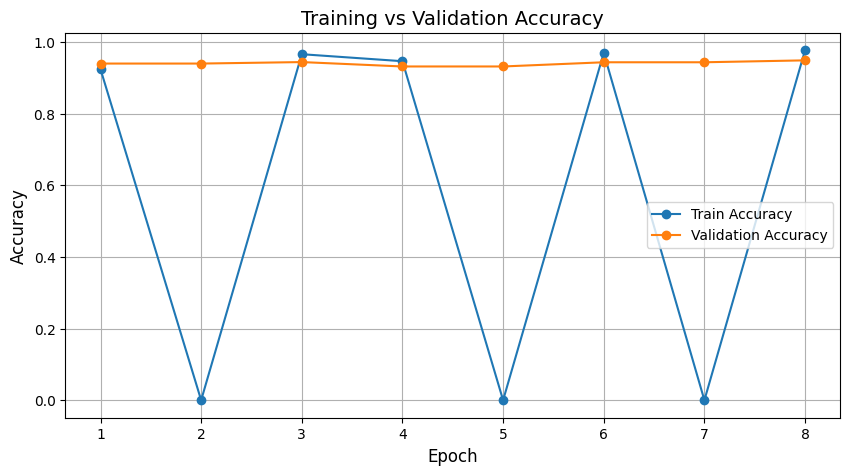

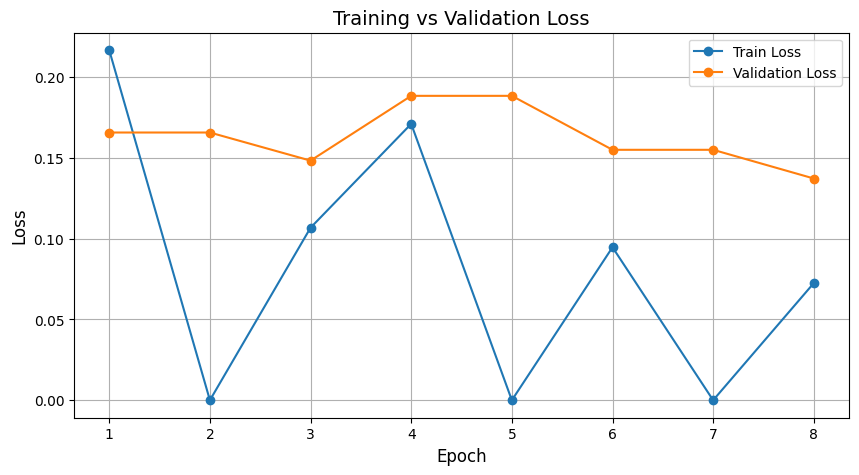

In [ ]:
import matplotlib.pyplot as plt

# ---------------- Merge head + fine-tune history ----------------
full_history = {}

for key in history_head.history.keys():
    full_history[key] = history_head.history[key] + history_ft.history.get(key, [])

# Total epochs used
total_epochs = len(full_history['loss'])
epochs_range = range(1, total_epochs + 1)

# ---------------- Plot Accuracy ----------------
plt.figure(figsize=(10,5))
plt.plot(epochs_range, full_history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(epochs_range, full_history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

# ---------------- Plot Loss ----------------
plt.figure(figsize=(10,5))
plt.plot(epochs_range, full_history['loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, full_history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()
